In [212]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import torch
import matplotlib.pyplot as plt
from src.data_processing.utils import set_seed
import pandas as pd
import joblib
from datetime import datetime
import yfinance as yf

from src.models.TimeGAN_torch.conditional_timegan import CondTimeGAN
from src.models.TimeGAN_torch.metrics.discriminative_metrics import discriminative_score_metrics
from src.models.TimeGAN_torch.metrics.predictive_metrics import predictive_score_metrics
from src.models.TimeGAN_torch.metrics.visualization_metrics import visualization
from src.data_processing.utils import TimeSeriesDataset, KFoldTimeSeries, save_synth_data, prepare_timegan_data_forecasting
from src.data_processing.signals import get_sp500_market_regime


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [197]:
# Need to set random seed for libraries, GPU, etc. for reproducibility 

set_seed(42)

Random seed set to: 42


## Set Network Parameters

seq_len is the length of the time series sequences. In this case seq_len=24 which represents 24 consecutive trading days
n_seq is the number of features, the CBOE VIX_history.csv dataset provided 4 features (CLOSE, LOW, HIGH, OPEN)

**going to incorportate monthly returns and "market regime" for now to use as conditional variables, will replace with markert-wide RV after testing the model**

In [201]:
# Newtork parameters
parameters = dict()

parameters['module'] = 'gru'
parameters['hidden_dim'] = 32
parameters['num_layers'] = 3
parameters['batch_size'] = 128
parameters['seq_len'] = 24
parameters['lr'] = 2e-4
parameters['device'] = torch.device("cuda" if torch.cuda.is_available() else "cpu")
parameters['epochs'] = 250
parameters['dataset_name'] = 'VIX'
parameters["cond_dim"] = 2

In [247]:
data_path = './data/real_data/VIX_History.csv'
scaler_path = './model_checkpoints/scalers/scaler_VIX.pkl'

# Load the VIX history data and remove unwanted initial rows
all_data = pd.read_csv(data_path).iloc[505:].reset_index(drop=True)

# Correct the date format in the DATE column
all_data['DATE'] = [datetime.strptime(date, '%m/%d/%Y').strftime('%Y-%m-%d') for date in all_data['DATE']]

# Fetch S&P 500 data for the corresponding date range
sp500_data = get_sp500_market_regime(start_date=all_data['DATE'].iloc[0], end_date=all_data['DATE'].iloc[-1])

# Merge the datasets on the DATE column to align them
merged_data = pd.merge(all_data, sp500_data, left_on='DATE', right_on='Date', how='inner')

# Remove rows with any NaN values to ensure data quality
cleaned_data = merged_data.dropna().reset_index(drop=True)

# Reset start of data since there monthly returns were calculated
cleaned_data = cleaned_data.iloc[1:]

# Remove the DATE column
cleaned_data.drop(['DATE'], axis=1, inplace=True)
cleaned_data.drop(['Date'], axis=1, inplace=True)

parameters['n_seq'] = cleaned_data.shape[1]

# Create dataset object
#dataset = TimeSeriesDataset(data=cleaned_data, seq_len=parameters['seq_len'], n_seq=parameters['n_seq'], scaler_path=scaler_path)

# Get train, val, test datasets
#train_dataset, val_dataset, test_dataset = dataset.get_datasets()

[*********************100%***********************]  1 of 1 completed


In [262]:
# Apply function to dataset
time_series_data, condition_data = prepare_timegan_data_forecasting(cleaned_data)

print(f"Time-Series Data Shape: {time_series_data.shape}")  # (n, 21, 4)
print(f"Conditioning Data Shape: {condition_data.shape}")  # (n, 4)

Time-Series Data Shape: (8295, 21, 4)
Conditioning Data Shape: (8295, 4)


## Run TimeGAN for synthetic time-series data generation

In [220]:
# Run TimeGAN
model = TimeGAN(parameters)

Model initialized with ID: VIX_20250227_012534_db74712f_n_layers3_seq_len24_n_seq4_hidden_dim32


In [221]:
model.train(train_dataset, 
            val_dataset, 
            ae_iters=parameters['epochs'], 
            sup_iters=parameters['epochs'], 
            joint_iters=parameters['epochs'], 
            patience = 10)

[Training] Phase 1: Autoencoder
[Autoencoder] Epoch 0/250, Train Loss: 3.1502, Val Loss: 2.1852
[Autoencoder] Epoch 10/250, Train Loss: 0.6039, Val Loss: 0.6648
[Autoencoder] Epoch 20/250, Train Loss: 0.3561, Val Loss: 0.3849
[Autoencoder] Epoch 30/250, Train Loss: 0.2790, Val Loss: 0.2805
[Autoencoder] Epoch 40/250, Train Loss: 0.2343, Val Loss: 0.2482
[Autoencoder] Epoch 50/250, Train Loss: 0.2134, Val Loss: 0.2092
[Autoencoder] Epoch 60/250, Train Loss: 0.1991, Val Loss: 0.2044
[Autoencoder] Epoch 70/250, Train Loss: 0.1907, Val Loss: 0.1949
[Autoencoder] Epoch 80/250, Train Loss: 0.1823, Val Loss: 0.1834
[Autoencoder] Epoch 90/250, Train Loss: 0.1750, Val Loss: 0.1770
[Autoencoder] Epoch 100/250, Train Loss: 0.1685, Val Loss: 0.1680
[Autoencoder] Early stopping at epoch 108 with best Val Loss: 0.1664
[Autoencoder] Restored best model from early stopping.
[Training] Phase 2: Supervisor
[Supervisor] Epoch 0/250, Train Loss: 0.6225, Val Loss: 0.5834
[Supervisor] Epoch 10/250, Train Lo

8.729520184653145

In [227]:
model.load_model('./model_checkpoints/VIX/VIX_20250227_012534_db74712f_n_layers3_seq_len24_n_seq4_hidden_dim32')

num_synthetic_samples = len(val_dataset) + parameters['seq_len'] - 1
synthetic_data = model.generate(num_samples=num_synthetic_samples)
print("synthetic_data shape:", synthetic_data.shape)

[Model Loaded] Successfully loaded model from ./model_checkpoints/VIX/VIX_20250227_012534_db74712f_n_layers3_seq_len24_n_seq4_hidden_dim32 (ID: VIX_20250227_012534_db74712f_n_layers3_seq_len24_n_seq4_hidden_dim32)


synthetic_data shape: (836, 24, 4)


## Evaluate the generated data

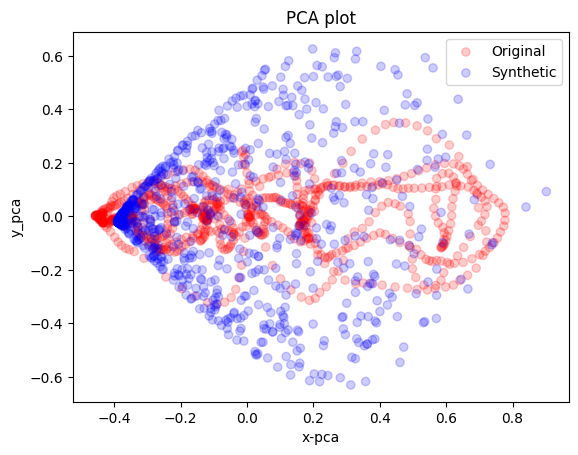

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 1626 samples in 0.001s...
[t-SNE] Computed neighbors for 1626 samples in 0.151s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1626
[t-SNE] Computed conditional probabilities for sample 1626 / 1626
[t-SNE] Mean sigma: 0.030827
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.748848
[t-SNE] KL divergence after 300 iterations: 1.127253


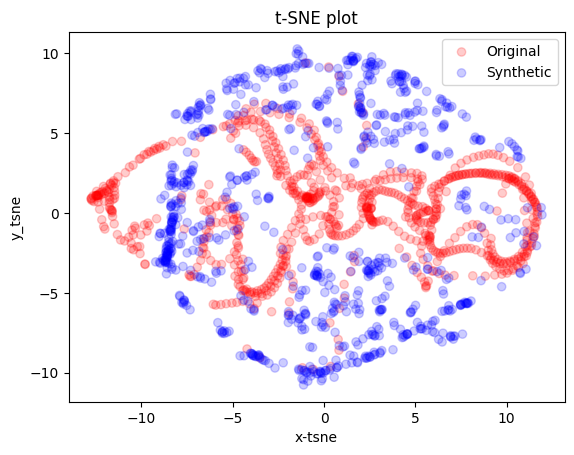

In [228]:
visualization(test_dataset, synthetic_data, 'pca')
visualization(test_dataset, synthetic_data, 'tsne')

## Inverse-transform generated sequences

The generated sequences are normalized using MinMax(), need to inverse transform the data

In [251]:
# Load the scaler
scaler_path = f'./model_checkpoints/scalers/scaler_{dataset_name}.pkl'
scaler = joblib.load(scaler_path)

# Reshape synthetic_data from (n_samples, n_timesteps, n_features) to (n_samples * n_timesteps, n_features)
n_samples, n_timesteps, n_features = synthetic_data.shape
synthetic_data_reshaped = synthetic_data.reshape(-1, n_features)

# Inverse transform
synthetic_data_inv = scaler.inverse_transform(synthetic_data_reshaped)

# Reshape back to (n_samples, n_timesteps, n_features)
# Each of the samples would represent a single block of time (e.g. synthetic_data_inv[i])
synthetic_data_inv = synthetic_data_inv.reshape(n_samples, n_timesteps, n_features)

# Example of a single block of 24 days
synth_df = pd.DataFrame(synthetic_data_inv[0], columns=all_data.columns)

synth_df.head()

,OPEN,HIGH,LOW,CLOSE
0,14.035061,14.947085,13.785007,14.353035
1,16.443285,16.076361,15.096717,16.053020
2,14.477314,15.106624,14.513026,15.009094
3,13.207664,14.238001,13.590878,13.922525
4,14.049278,14.566343,13.713311,14.283473


In [250]:
save_synth_data(synthetic_data_inv, 
                save_dir='./data/synthetic_data',
                dataset_name=parameters['dataset_name'],
                col_names=all_data.columns.tolist())

Saved 836 VIX (seq_len=24) generated synthetic samples to ./data/synthetic_data/VIX/24
